Dataset shape: (2240, 29)

First 5 rows:


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0



Columns:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Missing values:
ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Acce

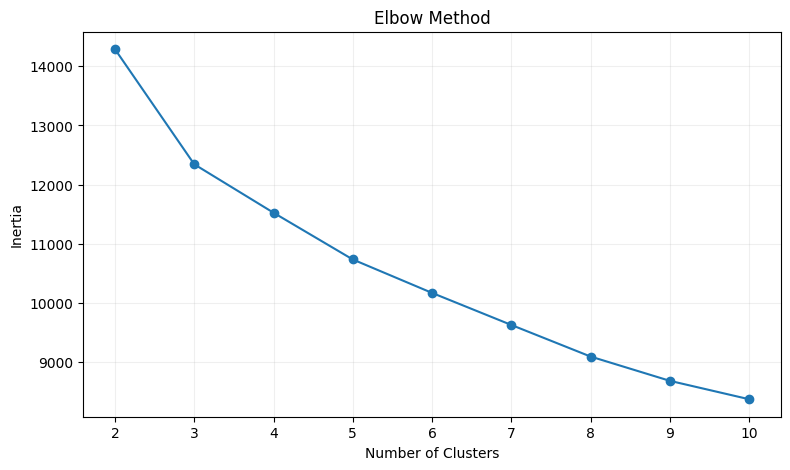

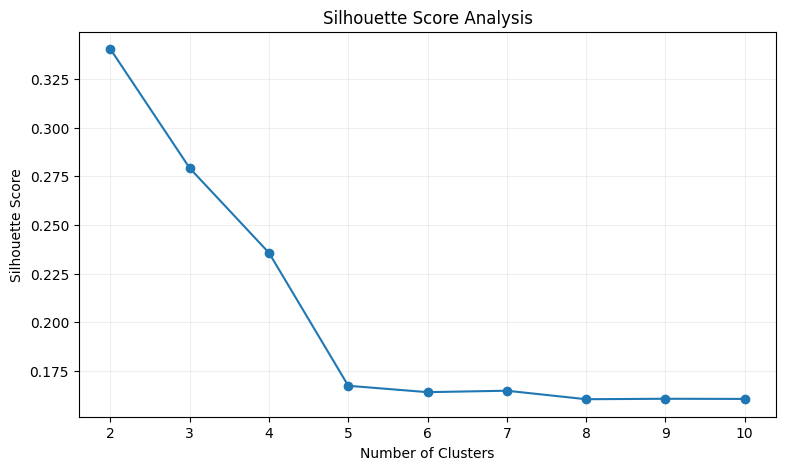


Recommended number of clusters: 2
Best silhouette score: 0.34

Cluster sizes:
Cluster
0    1188
1    1049
Name: count, dtype: int64

Cluster characteristics:


,Age,Income,Recency,TotalSpent,TotalPurchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth
Cluster,,,,,,,,,,
0,43.15,36641.84,48.85,135.60,6.69,2.30,2.52,0.68,3.49,6.47
1,47.31,69878.17,49.40,1138.18,19.17,2.35,5.86,4.91,8.40,4.01



Cluster median values:


,Age,Income,Recency,TotalSpent,TotalPurchases
Cluster,,,,,
0,42.0,36630.5,49.0,74.0,6.0
1,47.0,69263.0,51.0,1089.0,19.0


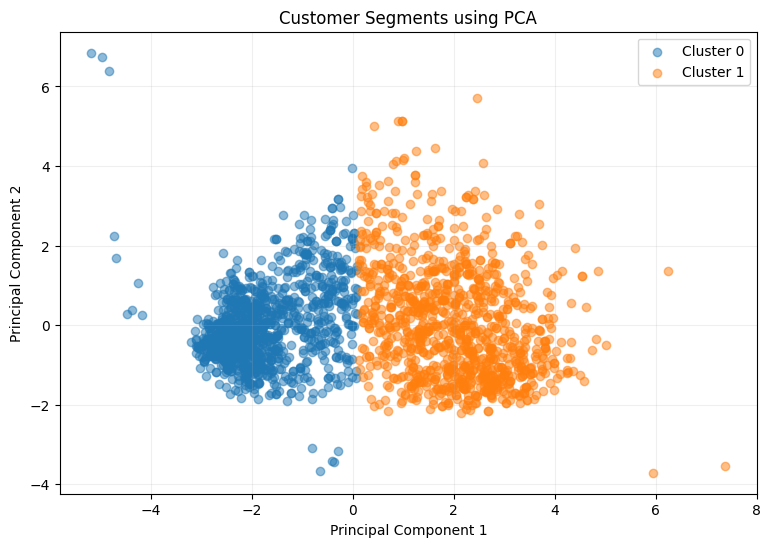

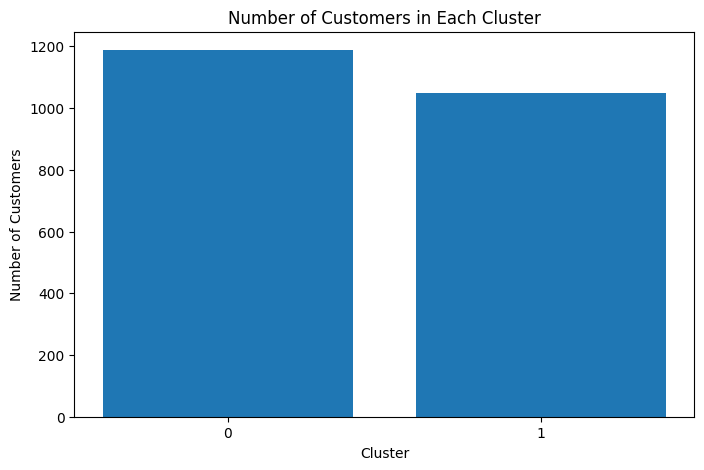


Customer segments:
Segment
Lower Spending Customers    1188
High Spending Customers     1049
Name: count, dtype: int64

Segment summary:


,Age,Income,Recency,TotalSpent,TotalPurchases,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
Segment,,,,,,,,,
High Spending Customers,47.31,69878.17,49.40,1138.18,19.17,2.35,5.86,4.91,8.40
Lower Spending Customers,43.15,36641.84,48.85,135.60,6.69,2.30,2.52,0.68,3.49



Segmented dataset saved to:
/kaggle/working/customer_segments.csv

TASK 3 COMPLETED
Customers: 2237
Clusters: 2
Silhouette score: 0.34


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA


# load dataset
file_path = "/kaggle/input/datasets/sagarchhabriya/customer-personality-analysis-dataset/marketing_campaign.csv"

df = pd.read_csv(
    file_path,
    sep="\t"
)

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())


# basic information
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())


# remove duplicates
df = df.drop_duplicates().copy()


# clean income column
df["Income"] = pd.to_numeric(
    df["Income"],
    errors="coerce"
)

df["Income"] = df["Income"].fillna(
    df["Income"].median()
)


# convert customer date
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    dayfirst=True,
    errors="coerce"
)

# calculate age
df["Age"] = 2014 - df["Year_Birth"]

# remove unrealistic ages
df = df[
    (df["Age"] >= 18) &
    (df["Age"] <= 100)
].copy()


# create total spending
spending_columns = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]

df["TotalSpent"] = df[spending_columns].sum(axis=1)


# total number of purchases
purchase_columns = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

df["TotalPurchases"] = df[purchase_columns].sum(axis=1)


print("\nData after preprocessing:", df.shape)


# features used for clustering
features = [
    "Age",
    "Income",
    "Recency",
    "TotalSpent",
    "TotalPurchases",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

X = df[features].copy()


# scale the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# check different values of k
inertia = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertia.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )


# elbow plot
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.grid(alpha=0.2)

plt.show()


# silhouette plot
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.grid(alpha=0.2)

plt.show()


# choose k using the best silhouette score
best_k = k_values[
    np.argmax(silhouette_scores)
]

print("\nRecommended number of clusters:", best_k)
print(
    "Best silhouette score:",
    round(max(silhouette_scores), 3)
)


# train final model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)


print("\nCluster sizes:")
print(df["Cluster"].value_counts().sort_index())


# cluster summary
summary = df.groupby("Cluster")[features].mean()

print("\nCluster characteristics:")
display(summary.round(2))


# median values are also useful
median_summary = df.groupby("Cluster")[
    [
        "Age",
        "Income",
        "Recency",
        "TotalSpent",
        "TotalPurchases"
    ]
].median()

print("\nCluster median values:")
display(median_summary.round(2))


# visualize clusters using PCA
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df["Cluster"].values


plt.figure(figsize=(9, 6))

for cluster in sorted(df["Cluster"].unique()):

    points = pca_df[
        pca_df["Cluster"] == cluster
    ]

    plt.scatter(
        points["PC1"],
        points["PC2"],
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

plt.title("Customer Segments using PCA")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(alpha=0.2)

plt.show()


# number of customers in each cluster
cluster_counts = (
    df["Cluster"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Customers in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()


# give simple names to the segments
cluster_spending = (
    df.groupby("Cluster")["TotalSpent"]
    .mean()
    .sort_values()
)

segment_names = {}

for i, cluster in enumerate(cluster_spending.index):

    if i == 0:
        segment_names[cluster] = "Lower Spending Customers"

    elif i == len(cluster_spending) - 1:
        segment_names[cluster] = "High Spending Customers"

    else:
        segment_names[cluster] = "Medium Spending Customers"


df["Segment"] = df["Cluster"].map(segment_names)


print("\nCustomer segments:")
print(df["Segment"].value_counts())


# final segment summary
segment_summary = df.groupby("Segment")[
    [
        "Age",
        "Income",
        "Recency",
        "TotalSpent",
        "TotalPurchases",
        "NumDealsPurchases",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases"
    ]
].mean()

print("\nSegment summary:")
display(segment_summary.round(2))


# save results
output_file = "/kaggle/working/customer_segments.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nSegmented dataset saved to:")
print(output_file)


print("\n==============================")
print("TASK 3 COMPLETED")
print("==============================")

print("Customers:", len(df))
print("Clusters:", best_k)
print(
    "Silhouette score:",
    round(max(silhouette_scores), 3)
)